# Random Forest Nested CV with Resampling Evidence

This notebook mirrors the baseline Random Forest workflow but adds train-fold-only random oversampling. It is intended to provide report evidence for whether resampling helps or hurts.

Important rule:

```text
Oversampling is applied only to training folds, never to validation or holdout rows.
```


## 1. Imports

In [1]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

warnings.filterwarnings("ignore")

## 2. Load Resampling Config

This notebook reads `json-parameters/random-forest/random_forest_resampling_params.json` and writes to separate resampling artifacts so the baseline RF result is not overwritten.


In [2]:
def find_repo_root():
    start_path = pathlib.Path(__file__).resolve().parent if "__file__" in globals() else pathlib.Path.cwd().resolve()
    for candidate in [start_path, *start_path.parents]:
        config_candidate = candidate / "json-parameters" / "random-forest" / "random_forest_resampling_params.json"
        if config_candidate.exists():
            return candidate, config_candidate
    raise FileNotFoundError("Could not locate json-parameters/random-forest/random_forest_resampling_params.json")


REPO_ROOT, CONFIG_PATH = find_repo_root()
with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print("Config loaded from:", CONFIG_PATH)
print("Search scoring:", config["search"]["scoring"])
print("Search iterations:", config["search"]["n_iter"])

Config loaded from: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/random-forest/random_forest_resampling_params.json
Search scoring: f1_macro
Search iterations: 50


## 3. Load Data and Build Features

Only configured feature columns are used. Raw identifier columns such as `constructorId` and `circuitId` can remain in the CSV but are excluded by config.

In [3]:
def validate_feature_list(name, cols, df_columns, forbidden_cols=None, allow_none=False):
    if cols is None and allow_none:
        return
    if not isinstance(cols, list):
        raise TypeError(f"config['data']['{name}'] must be a list or null")

    forbidden_cols = forbidden_cols or []
    duplicated = sorted({col for col in cols if cols.count(col) > 1})
    missing = sorted(set(cols) - set(df_columns))
    forbidden = sorted(set(cols) & set(forbidden_cols))

    if duplicated:
        raise ValueError(f"Duplicate columns in {name}: {duplicated}")
    if missing:
        raise ValueError(f"Columns in {name} not found in dataset: {missing}")
    if forbidden:
        raise ValueError(f"{name} includes non-feature columns: {forbidden}")


def build_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


data_cfg = config["data"]
target_col = data_cfg["target_column"]
drop_cols = data_cfg["drop_columns"]
feature_cols = data_cfg.get("feature_columns")
excluded_cols = data_cfg.get("excluded_feature_columns", [])
categorical_cols = data_cfg.get("categorical_feature_columns", [])

DATA_PATH = REPO_ROOT / data_cfg.get("dataset_path", "dataset/outputs/prediction.csv")
df = pd.read_csv(DATA_PATH).sort_values(data_cfg["sort_by"]).reset_index(drop=True)

validate_feature_list("feature_columns", feature_cols, df.columns, drop_cols + [target_col], allow_none=True)
validate_feature_list("excluded_feature_columns", excluded_cols, df.columns)
validate_feature_list("categorical_feature_columns", categorical_cols, df.columns)

if feature_cols is not None:
    overlap = sorted(set(feature_cols) & set(excluded_cols))
    if overlap:
        raise ValueError(f"Columns cannot be both active and excluded: {overlap}")
    raw_X = df[feature_cols].copy()
else:
    raw_X = df.drop(columns=drop_cols + [target_col] + excluded_cols)

raw_feature_names = raw_X.columns.tolist()
missing_categorical = sorted(set(categorical_cols) - set(raw_feature_names))
if missing_categorical:
    raise ValueError(
        "categorical_feature_columns must be active model features. "
        f"Missing from feature set: {missing_categorical}"
    )

numeric_cols = [col for col in raw_feature_names if col not in categorical_cols]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_col])

print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
print("Years:", sorted(df["year"].unique().tolist()))
print("Classes:", dict(enumerate(label_encoder.classes_)))
print("Raw feature count:", len(raw_feature_names))
print("Categorical feature count:", len(categorical_cols))
print("Excluded feature columns:", excluded_cols)
print()
print("Target distribution:")
print(df[target_col].value_counts())

Dataset: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/dataset/outputs/prediction.csv
Shape: (2344, 38)
Years: [2021, 2022, 2023, 2024, 2025, 2026]
Classes: {0: 'no_points', 1: 'podium', 2: 'points'}
Raw feature count: 25
Categorical feature count: 0
Excluded feature columns: ['constructorId', 'circuitId']

Target distribution:
target
no_points    1174
points        819
podium        351
Name: count, dtype: int64


## 4. Chronological Holdout Split

Nested CV runs only inside train/development data. The holdout season is evaluated once after final refit.

In [4]:
holdout_cfg = data_cfg.get("holdout", {})
test_years = sorted(int(year) for year in holdout_cfg.get("test_years", [2025]))
exclude_years = sorted(int(year) for year in holdout_cfg.get("exclude_years", []))

if not test_years:
    raise ValueError("config['data']['holdout']['test_years'] must contain at least one year")
if set(test_years) & set(exclude_years):
    raise ValueError("The same year cannot be both a holdout test year and an excluded year")

test_mask = df["year"].isin(test_years)
exclude_mask = df["year"].isin(exclude_years)
train_dev_mask = ~(test_mask | exclude_mask)

if not train_dev_mask.any():
    raise ValueError("Holdout split leaves no rows for training/development")
if not test_mask.any():
    raise ValueError("Holdout split leaves no rows for final testing")

train_max_date = pd.to_datetime(df.loc[train_dev_mask, "date"]).max()
test_min_date = pd.to_datetime(df.loc[test_mask, "date"]).min()
if train_max_date >= test_min_date:
    raise ValueError(
        "Holdout must be strictly after the training/development period. "
        f"Got train max date {train_max_date.date()} and test min date {test_min_date.date()}."
    )

train_dev_idx = np.flatnonzero(train_dev_mask.to_numpy())
holdout_idx = np.flatnonzero(test_mask.to_numpy())

df_train_dev = df.iloc[train_dev_idx].reset_index(drop=True)
df_holdout = df.iloc[holdout_idx].reset_index(drop=True)
raw_X_train_dev = raw_X.iloc[train_dev_idx].reset_index(drop=True)
raw_X_holdout = raw_X.iloc[holdout_idx].reset_index(drop=True)
y_train_dev = y[train_dev_idx]
y_holdout = y[holdout_idx]

onehot_encoder = build_onehot_encoder()
if categorical_cols:
    train_cat = onehot_encoder.fit_transform(raw_X_train_dev[categorical_cols].astype(str))
    holdout_cat = onehot_encoder.transform(raw_X_holdout[categorical_cols].astype(str))
    encoded_categorical_names = onehot_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    train_cat = np.empty((len(raw_X_train_dev), 0))
    holdout_cat = np.empty((len(raw_X_holdout), 0))
    encoded_categorical_names = []

X_train_dev = pd.concat(
    [
        raw_X_train_dev[numeric_cols].reset_index(drop=True),
        pd.DataFrame(train_cat, columns=encoded_categorical_names),
    ],
    axis=1,
)
X_holdout = pd.concat(
    [
        raw_X_holdout[numeric_cols].reset_index(drop=True),
        pd.DataFrame(holdout_cat, columns=encoded_categorical_names),
    ],
    axis=1,
)
feature_names = X_train_dev.columns.tolist()

print("Train/development years:", sorted(df_train_dev["year"].unique().tolist()))
print("Holdout years:", test_years)
print("Excluded years:", exclude_years)
print("Train/development rows:", len(df_train_dev))
print("Holdout rows:", len(df_holdout))
print("Train/development races:", df_train_dev["raceId"].nunique())
print("Holdout races:", df_holdout["raceId"].nunique())
print("Encoded feature count:", len(feature_names))

Train/development years: [2021, 2022, 2023, 2024]
Holdout years: [2025]
Excluded years: [2026]
Train/development rows: 1799
Holdout rows: 479
Train/development races: 90
Holdout races: 24
Encoded feature count: 25


## 5. Race-Level Time-Series CV Helper

The split is applied to whole races instead of rows, so drivers from the same race never appear in both train and validation within a fold.

,fold,train_rows,validation_rows,train_races,validation_races,race_overlap
0,1,300,300,15,15,0
1,2,600,300,30,15,0
2,3,900,300,45,15,0
3,4,1200,299,60,15,0
4,5,1499,300,75,15,0


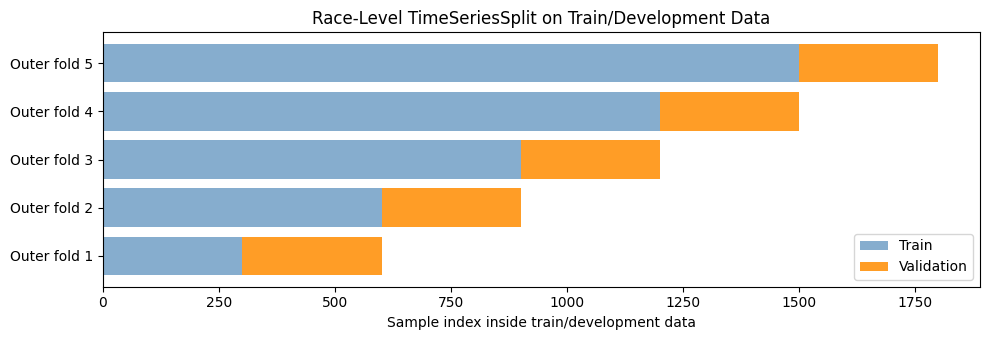

In [5]:
def make_race_time_series_splits(df_source, n_splits):
    race_order = (
        df_source[["raceId", "date"]]
        .drop_duplicates()
        .sort_values("date")
        .reset_index(drop=True)
    )
    race_ids = race_order["raceId"].to_numpy()
    race_cv = TimeSeriesSplit(n_splits=n_splits)

    for train_race_idx, test_race_idx in race_cv.split(race_ids):
        train_races = set(race_ids[train_race_idx])
        test_races = set(race_ids[test_race_idx])
        train_idx = np.flatnonzero(df_source["raceId"].isin(train_races).to_numpy())
        test_idx = np.flatnonzero(df_source["raceId"].isin(test_races).to_numpy())
        yield train_idx, test_idx


outer_n_splits = config["cv"]["outer_n_splits"]
inner_n_splits = config["cv"]["inner_n_splits"]
outer_splits = list(make_race_time_series_splits(df_train_dev, outer_n_splits))

split_rows = []
for fold_idx, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    train_races = df_train_dev.iloc[train_idx]["raceId"].nunique()
    test_races = df_train_dev.iloc[test_idx]["raceId"].nunique()
    overlap = set(df_train_dev.iloc[train_idx]["raceId"]) & set(df_train_dev.iloc[test_idx]["raceId"])
    split_rows.append({
        "fold": fold_idx,
        "train_rows": len(train_idx),
        "validation_rows": len(test_idx),
        "train_races": train_races,
        "validation_races": test_races,
        "race_overlap": len(overlap),
    })

split_df = pd.DataFrame(split_rows)
display(split_df)

fig, ax = plt.subplots(figsize=(10, 3.5))
for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
    ax.barh(
        y=fold_idx,
        width=len(train_idx),
        left=train_idx[0],
        color="steelblue",
        alpha=0.65,
        label="Train" if fold_idx == 0 else None,
    )
    ax.barh(
        y=fold_idx,
        width=len(test_idx),
        left=test_idx[0],
        color="darkorange",
        alpha=0.85,
        label="Validation" if fold_idx == 0 else None,
    )

ax.set_yticks(range(outer_n_splits))
ax.set_yticklabels([f"Outer fold {idx + 1}" for idx in range(outer_n_splits)])
ax.set_xlabel("Sample index inside train/development data")
ax.set_title("Race-Level TimeSeriesSplit on Train/Development Data")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6. Oversampled Random Forest Estimator

This wrapper makes oversampling compatible with `RandomizedSearchCV`. The wrapper receives only the current training fold in `fit()`, performs random oversampling inside that fold, and then fits a normal `RandomForestClassifier`.

Validation folds and the final holdout are never resampled.

In [6]:
class OversampledRandomForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        criterion="gini",
        bootstrap=True,
        max_samples=None,
        class_weight=None,
        resampling_strategy="none",
        resampling_ratio=1.0,
        random_state=None,
        n_jobs=None,
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.criterion = criterion
        self.bootstrap = bootstrap
        self.max_samples = max_samples
        self.class_weight = class_weight
        self.resampling_strategy = resampling_strategy
        self.resampling_ratio = resampling_ratio
        self.random_state = random_state
        self.n_jobs = n_jobs

    def _oversample(self, X, y):
        strategy = self.resampling_strategy
        ratio = float(self.resampling_ratio)
        if strategy in (None, "none") or ratio <= 0:
            return X, y

        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        classes, counts = np.unique(y_arr, return_counts=True)
        majority_count = int(counts.max())
        min_count = int(counts.min())
        rng = np.random.default_rng(self.random_state)

        selected_indices = [np.arange(len(y_arr))]
        for cls, count in zip(classes, counts):
            is_majority = count == majority_count
            is_minority = count == min_count

            if strategy == "minority" and not is_minority:
                continue
            if strategy == "not_majority" and is_majority:
                continue
            if strategy not in ("minority", "not_majority"):
                raise ValueError(f"Unsupported resampling_strategy: {strategy!r}")

            target_count = int(round(count + (majority_count - count) * ratio))
            target_count = min(target_count, majority_count)
            extra_needed = max(0, target_count - int(count))
            if extra_needed == 0:
                continue

            cls_indices = np.flatnonzero(y_arr == cls)
            extra_indices = rng.choice(cls_indices, size=extra_needed, replace=True)
            selected_indices.append(extra_indices)

        final_indices = np.concatenate(selected_indices)
        rng.shuffle(final_indices)
        return X_arr[final_indices], y_arr[final_indices]

    def fit(self, X, y):
        X_resampled, y_resampled = self._oversample(X, y)
        self.estimator_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features,
            criterion=self.criterion,
            bootstrap=self.bootstrap,
            max_samples=self.max_samples,
            class_weight=self.class_weight,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
        )
        self.estimator_.fit(X_resampled, y_resampled)
        self.classes_ = self.estimator_.classes_
        self.n_features_in_ = self.estimator_.n_features_in_
        self.feature_importances_ = self.estimator_.feature_importances_
        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


print("Oversampling strategies searched:", config["param_distribution"].get("resampling_strategy"))
print("Oversampling ratios searched:", config["param_distribution"].get("resampling_ratio"))

Oversampling strategies searched: ['none', 'minority', 'not_majority']
Oversampling ratios searched: [0.5, 0.75, 1.0]


## 7. Nested Cross-Validation

The inner split tunes both Random Forest hyperparameters and resampling choices. Resampling is applied only inside each training fold.


In [7]:
def normalize_param_distribution(param_distribution):
    return {
        key: [None if value is None else value for value in values]
        for key, values in param_distribution.items()
    }


model_cfg = config["model"]
search_cfg = config["search"]
param_dist = normalize_param_distribution(config["param_distribution"])
X_train_dev_arr = X_train_dev.to_numpy()

outer_scores_f1 = []
outer_scores_bal_acc = []
outer_best_params = []
outer_feature_importances = []
outer_predictions = []

print(f"Outer folds: {outer_n_splits}")
print(f"Inner folds: {inner_n_splits}")
print(f"Search iterations: {search_cfg['n_iter']}")
print(f"Scoring: {search_cfg['scoring']}")

for fold_num, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    X_train, X_test = X_train_dev_arr[train_idx], X_train_dev_arr[test_idx]
    y_train, y_test = y_train_dev[train_idx], y_train_dev[test_idx]
    df_train = df_train_dev.iloc[train_idx].reset_index(drop=True)
    inner_splits = list(make_race_time_series_splits(df_train, inner_n_splits))

    search = RandomizedSearchCV(
        estimator=OversampledRandomForestClassifier(
            random_state=model_cfg["random_state"],
            n_jobs=model_cfg["n_jobs"],
        ),
        param_distributions=param_dist,
        n_iter=search_cfg["n_iter"],
        scoring=search_cfg["scoring"],
        cv=inner_splits,
        random_state=search_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
        refit=True,
    )
    search.fit(X_train, y_train)
    y_pred = search.best_estimator_.predict(X_test)

    fold_f1 = f1_score(y_test, y_pred, average="macro")
    fold_bal_acc = balanced_accuracy_score(y_test, y_pred)

    outer_scores_f1.append(fold_f1)
    outer_scores_bal_acc.append(fold_bal_acc)
    outer_best_params.append(search.best_params_)
    outer_feature_importances.append(search.best_estimator_.feature_importances_)
    outer_predictions.append((y_test, y_pred))

    print(
        f"Fold {fold_num}/{outer_n_splits} | "
        f"macro F1={fold_f1:.4f} | "
        f"balanced acc={fold_bal_acc:.4f} | "
        f"best inner score={search.best_score_:.4f}"
    )

nested_cv_summary = {
    "outer_folds": outer_n_splits,
    "inner_folds": inner_n_splits,
    "mean_macro_f1": round(float(np.mean(outer_scores_f1)), 4),
    "std_macro_f1": round(float(np.std(outer_scores_f1)), 4),
    "mean_balanced_acc": round(float(np.mean(outer_scores_bal_acc)), 4),
    "std_balanced_acc": round(float(np.std(outer_scores_bal_acc)), 4),
}

print()
print("Nested CV summary:")
print(json.dumps(nested_cv_summary, indent=2))

Outer folds: 5
Inner folds: 3
Search iterations: 50
Scoring: f1_macro
Fold 1/5 | macro F1=0.6635 | balanced acc=0.6595 | best inner score=0.6542
Fold 2/5 | macro F1=0.6859 | balanced acc=0.7078 | best inner score=0.6884
Fold 3/5 | macro F1=0.6999 | balanced acc=0.7161 | best inner score=0.6923
Fold 4/5 | macro F1=0.6440 | balanced acc=0.6778 | best inner score=0.7059
Fold 5/5 | macro F1=0.7042 | balanced acc=0.7175 | best inner score=0.6918

Nested CV summary:
{
  "outer_folds": 5,
  "inner_folds": 3,
  "mean_macro_f1": 0.6795,
  "std_macro_f1": 0.0227,
  "mean_balanced_acc": 0.6957,
  "std_balanced_acc": 0.0231
}


## 8. Nested CV Diagnostics

This section shows the nested-CV fold metrics, pooled outer-fold classification behavior, and mean Random Forest feature importance across outer folds.


Per-fold scores:


,outer_fold,macro_f1,balanced_accuracy
0,1,0.6635,0.6595
1,2,0.6859,0.7078
2,3,0.6999,0.7161
3,4,0.6440,0.6778
4,5,0.7042,0.7175


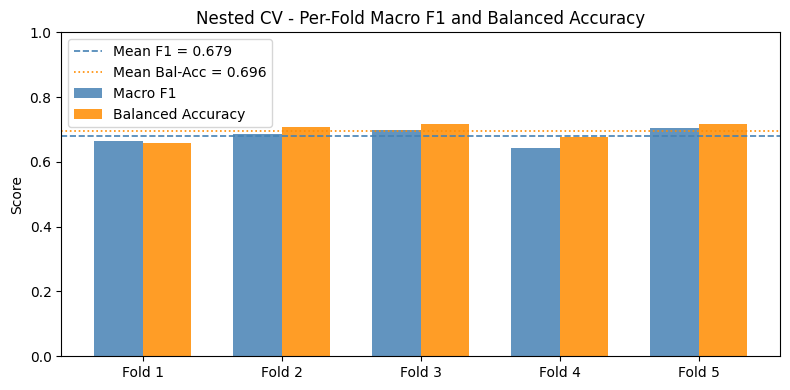


Pooled outer-fold classification report:
              precision    recall  f1-score   support

   no_points     0.8077    0.7850    0.7962       749
      podium     0.5899    0.7289    0.6521       225
      points     0.6105    0.5733    0.5914       525

    accuracy                         0.7025      1499
   macro avg     0.6694    0.6958    0.6799      1499
weighted avg     0.7060    0.7025    0.7028      1499

Pooled outer-fold confusion matrix:


,pred_no_points,pred_podium,pred_points
true_no_points,588,27,134
true_podium,3,164,58
true_points,137,87,301


Top 20 mean feature importances across outer folds:


,feature,mean_importance,std_importance
1,qualifying_position,0.2106,0.0457
0,grid,0.1199,0.0170
4,driver_std_position_prev,0.0966,0.0130
6,constructor_std_position_prev,0.0653,0.0119
12,driver_points_avg_last3,0.0606,0.0113
17,driver_dnf_rate_historical,0.0515,0.0141
13,constructor_avg_position_last3,0.0487,0.0048
11,driver_podium_rate_last10,0.0458,0.0169
18,points_gap_to_leader,0.0363,0.0029
5,constructor_std_points_prev,0.0360,0.0101


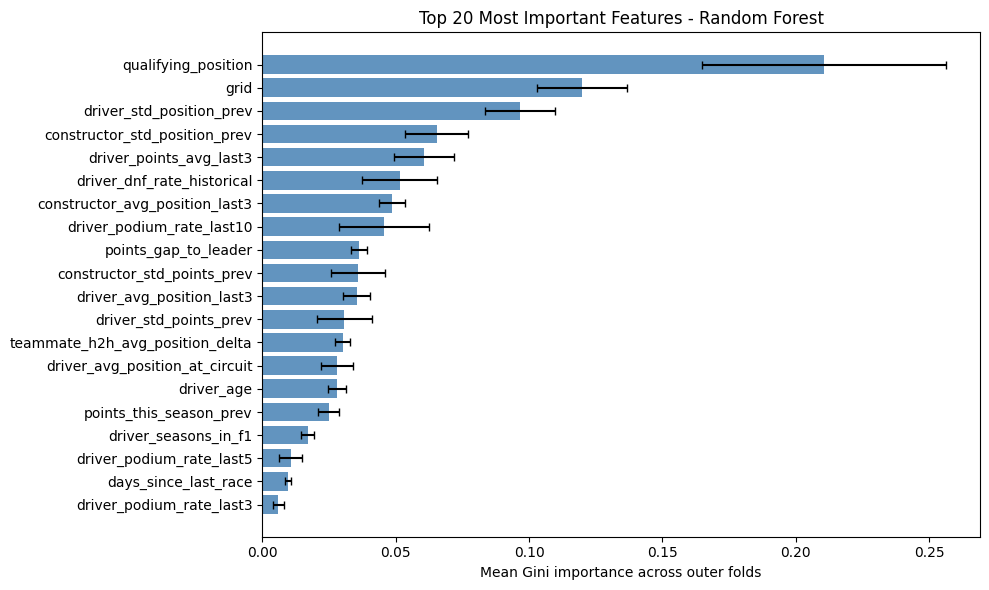

Best hyperparameters selected per outer fold:


,resampling_strategy,resampling_ratio,n_estimators,min_samples_split,min_samples_leaf,max_samples,max_features,max_depth,criterion,class_weight,bootstrap
0,none,0.5,500,10,4,0.75,sqrt,8.0,gini,None,True
1,minority,0.5,300,10,4,0.60,0.4,NaN,log_loss,None,True
2,none,0.5,500,20,2,0.75,0.3,8.0,log_loss,balanced,True
3,not_majority,1.0,300,30,1,0.75,0.4,12.0,entropy,None,True
4,none,1.0,300,20,2,0.75,0.4,NaN,log_loss,None,True


In [8]:
scores_df = pd.DataFrame({
    "outer_fold": range(1, outer_n_splits + 1),
    "macro_f1": outer_scores_f1,
    "balanced_accuracy": outer_scores_bal_acc,
})

print("Per-fold scores:")
display(scores_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(outer_n_splits)
width = 0.35

ax.bar(x - width / 2, outer_scores_f1, width, label="Macro F1", color="steelblue", alpha=0.85)
ax.bar(x + width / 2, outer_scores_bal_acc, width, label="Balanced Accuracy", color="darkorange", alpha=0.85)
ax.axhline(np.mean(outer_scores_f1), color="steelblue", linestyle="--", linewidth=1.2, label=f"Mean F1 = {np.mean(outer_scores_f1):.3f}")
ax.axhline(np.mean(outer_scores_bal_acc), color="darkorange", linestyle=":", linewidth=1.2, label=f"Mean Bal-Acc = {np.mean(outer_scores_bal_acc):.3f}")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {idx + 1}" for idx in range(outer_n_splits)])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Nested CV - Per-Fold Macro F1 and Balanced Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

all_y_true = np.concatenate([yt for yt, _ in outer_predictions])
all_y_pred = np.concatenate([yp for _, yp in outer_predictions])

print()
print("Pooled outer-fold classification report:")
print(classification_report(all_y_true, all_y_pred, target_names=label_encoder.classes_, digits=4))

print("Pooled outer-fold confusion matrix:")
display(pd.DataFrame(
    confusion_matrix(all_y_true, all_y_pred),
    index=[f"true_{name}" for name in label_encoder.classes_],
    columns=[f"pred_{name}" for name in label_encoder.classes_],
))

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_importance": np.mean(np.array(outer_feature_importances), axis=0),
    "std_importance": np.std(np.array(outer_feature_importances), axis=0),
}).sort_values("mean_importance", ascending=False)

print("Top 20 mean feature importances across outer folds:")
display(importance_df.head(20).round(4))

TOP_N = min(20, len(importance_df))
plot_df = importance_df.head(TOP_N).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    plot_df["feature"],
    plot_df["mean_importance"],
    xerr=plot_df["std_importance"],
    color="steelblue",
    alpha=0.85,
    capsize=3,
)
ax.set_xlabel("Mean Gini importance across outer folds")
ax.set_title(f"Top {TOP_N} Most Important Features - Random Forest")
plt.tight_layout()
plt.show()

print("Best hyperparameters selected per outer fold:")
display(pd.DataFrame(outer_best_params))


## 9. Final Model and Holdout Evaluation

After nested CV, run one final hyperparameter search on all train/development data and evaluate once on the untouched holdout season.

In [9]:
final_search = RandomizedSearchCV(
    estimator=OversampledRandomForestClassifier(
        random_state=model_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
    ),
    param_distributions=param_dist,
    n_iter=search_cfg["n_iter"],
    scoring=search_cfg["scoring"],
    cv=list(make_race_time_series_splits(df_train_dev, inner_n_splits)),
    random_state=search_cfg["random_state"],
    n_jobs=model_cfg["n_jobs"],
    refit=True,
)
final_search.fit(X_train_dev_arr, y_train_dev)

final_rf = final_search.best_estimator_
final_params = final_search.best_params_
X_holdout_arr = X_holdout.to_numpy()
holdout_pred = final_rf.predict(X_holdout_arr)

label_order_names = [name for name in ["podium", "points", "no_points"] if name in label_encoder.classes_]
label_order = label_encoder.transform(label_order_names)

holdout_metrics = {
    "accuracy": accuracy_score(y_holdout, holdout_pred),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, holdout_pred),
    "macro_precision": precision_score(y_holdout, holdout_pred, average="macro"),
    "macro_recall": recall_score(y_holdout, holdout_pred, average="macro"),
    "macro_f1": f1_score(y_holdout, holdout_pred, average="macro"),
    "weighted_precision": precision_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_recall": recall_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_f1": f1_score(y_holdout, holdout_pred, average="weighted"),
    "matthews_corrcoef": matthews_corrcoef(y_holdout, holdout_pred),
    "cohen_kappa": cohen_kappa_score(y_holdout, holdout_pred),
}

holdout_report = classification_report(
    y_holdout,
    holdout_pred,
    labels=label_order,
    target_names=label_order_names,
    digits=4,
    output_dict=True,
)

per_label_metrics_df = (
    pd.DataFrame(holdout_report)
    .T
    .loc[label_order_names, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1_score"})
)
per_label_metrics_df[["precision", "recall", "f1_score"]] = per_label_metrics_df[
    ["precision", "recall", "f1_score"]
].round(4)
per_label_metrics_df["support"] = per_label_metrics_df["support"].astype(int)

holdout_cm = confusion_matrix(y_holdout, holdout_pred, labels=label_order)
holdout_cm_df = pd.DataFrame(
    holdout_cm,
    index=[f"true_{name}" for name in label_order_names],
    columns=[f"pred_{name}" for name in label_order_names],
)

overall_metrics_df = pd.DataFrame(
    [(name, round(float(value), 4)) for name, value in holdout_metrics.items()],
    columns=["metric", "value"],
)

print("Best train/development search params:")
print(json.dumps(final_params, indent=2, default=str))
print(f"Best train/development CV score: {final_search.best_score_:.4f}")

print()
print("Overall holdout metrics:")
display(overall_metrics_df)

print()
print("Per-label holdout metrics:")
display(per_label_metrics_df)

print()
print("Holdout confusion matrix:")
display(holdout_cm_df)

print()
print("Holdout classification report:")
print(classification_report(
    y_holdout,
    holdout_pred,
    labels=label_order,
    target_names=label_order_names,
    digits=4,
))

Best train/development search params:
{
  "resampling_strategy": "none",
  "resampling_ratio": 0.5,
  "n_estimators": 500,
  "min_samples_split": 20,
  "min_samples_leaf": 1,
  "max_samples": 0.75,
  "max_features": 0.3,
  "max_depth": null,
  "criterion": "gini",
  "class_weight": null,
  "bootstrap": true
}
Best train/development CV score: 0.6979

Overall holdout metrics:


,metric,value
0,accuracy,0.6806
1,balanced_accuracy,0.6859
2,macro_precision,0.6742
3,macro_recall,0.6859
4,macro_f1,0.6788
5,weighted_precision,0.6743
6,weighted_recall,0.6806
7,weighted_f1,0.6763
8,matthews_corrcoef,0.4721
9,cohen_kappa,0.4711



Per-label holdout metrics:


,precision,recall,f1_score,support
podium,0.7179,0.7778,0.7467,72
points,0.5705,0.5060,0.5363,168
no_points,0.7341,0.7741,0.7536,239



Holdout confusion matrix:


,pred_podium,pred_points,pred_no_points
true_podium,56,13,3
true_points,19,85,64
true_no_points,3,51,185



Holdout classification report:
              precision    recall  f1-score   support

      podium     0.7179    0.7778    0.7467        72
      points     0.5705    0.5060    0.5363       168
   no_points     0.7341    0.7741    0.7536       239

    accuracy                         0.6806       479
   macro avg     0.6742    0.6859    0.6788       479
weighted avg     0.6743    0.6806    0.6763       479



## 10. Save Artifacts

In [10]:
output_cfg = config.get("output", {})
model_path = REPO_ROOT / output_cfg.get(
    "model_path",
    "models_training/random-forest/rf_final_model.joblib",
)
best_params_path = REPO_ROOT / output_cfg.get(
    "best_params_path",
    "json-parameters/random-forest/random_forest_best_params.json",
)

model_path.parent.mkdir(parents=True, exist_ok=True)
best_params_path.parent.mkdir(parents=True, exist_ok=True)

model_artifact = {
    "model": final_rf,
    "onehot_encoder": onehot_encoder,
    "raw_feature_names": raw_feature_names,
    "numeric_feature_names": numeric_cols,
    "categorical_feature_names": categorical_cols,
    "encoded_feature_names": feature_names,
    "label_encoder": label_encoder,
}
joblib.dump(model_artifact, model_path)

output_record = {
    "dataset_path": str(DATA_PATH.relative_to(REPO_ROOT)),
    "features_used": feature_names,
    "raw_features_used": raw_feature_names,
    "categorical_features_encoded": categorical_cols,
    "features_excluded": excluded_cols,
    "holdout_split": {
        "train_development_years": sorted(int(year) for year in df_train_dev["year"].unique()),
        "holdout_test_years": test_years,
        "excluded_years": exclude_years,
        "train_development_rows": int(len(df_train_dev)),
        "holdout_test_rows": int(len(df_holdout)),
        "train_development_races": int(df_train_dev["raceId"].nunique()),
        "holdout_test_races": int(df_holdout["raceId"].nunique()),
    },
    "nested_cv_summary": nested_cv_summary,
    "final_search_summary": {
        "search_method": "RandomizedSearchCV",
        "n_iter": search_cfg["n_iter"],
        "scoring": search_cfg["scoring"],
        "cv_folds": inner_n_splits,
        "best_cv_score": round(float(final_search.best_score_), 4),
    },
    "final_holdout_metrics": {
        name: round(float(value), 4) for name, value in holdout_metrics.items()
    },
    "final_holdout_per_label_metrics": per_label_metrics_df.to_dict(orient="index"),
    "final_holdout_classification_report": holdout_report,
    "final_holdout_confusion_matrix": {
        "labels": label_order_names,
        "matrix": holdout_cm.tolist(),
    },
    "final_hyperparameters": final_params,
    "model_path": str(model_path.relative_to(REPO_ROOT)),
    "fixed_model_settings": {
        "class_weight": model_cfg["class_weight"],
        "random_state": model_cfg["random_state"],
    },
}

with open(best_params_path, "w") as f:
    json.dump(output_record, f, indent=2, default=str)

print("Model artifact saved to:", model_path)
print("Best params and metrics saved to:", best_params_path)
print(json.dumps(output_record["final_holdout_metrics"], indent=2))

Model artifact saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_training/random-forest/rf_final_model_resampling_evidence.joblib
Best params and metrics saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/random-forest/random_forest_best_resampling_evidence_params.json
{
  "accuracy": 0.6806,
  "balanced_accuracy": 0.6859,
  "macro_precision": 0.6742,
  "macro_recall": 0.6859,
  "macro_f1": 0.6788,
  "weighted_precision": 0.6743,
  "weighted_recall": 0.6806,
  "weighted_f1": 0.6763,
  "matthews_corrcoef": 0.4721,
  "cohen_kappa": 0.4711
}


## 11. Summary

Use the holdout metrics as the final Random Forest result. Nested CV is used for model-selection evaluation, but it is not a substitute for the untouched future-season holdout.